# HuggingFace Transformers: API, Models and Fine-Tuning Techniques - Day 4

In [1]:
import sys
import torch
import transformers
import PIL

print("Python version:", sys.version)
print("Torch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("PIL version:", PIL.__version__)

Python version: 3.11.14 | packaged by conda-forge | (main, Oct 13 2025, 14:29:50) [Clang 19.1.7 ]
Torch version: 2.10.0
Transformers version: 4.57.6
PIL version: 12.3.0


### LLM Fine-tuning: Optimization and Techniques

#### PEFT - Parameter-Efficient-Fine-Tuning

PEFT offers parameter-efficient methods for finetuning large pretrained models. 

The traditional paradigm is to finetune all of a model’s parameters for each downstream task, but this is becoming exceedingly costly and impractical because of the enormous number of parameters in models today.

PEFT involves the following strategies for making fine-tuning efficient:
  - **LoRA (Low-Rank Adaptation)**: https://arxiv.org/pdf/2106.09685.
  - **Prompt Tuning Techniques**:
     * **Prompt Tuning**: https://arxiv.org/pdf/2104.08691.pdf
     * **Prefix Tuning (P-Tuning)**: https://arxiv.org/pdf/2103.10385.pdf
     * **P-Tuning v2**: https://arxiv.org/pdf/2110.07602.pdf
---

##### LoRA
Instead, it is more efficient to train a smaller number of prompt parameters or use a reparametrization method like low-rank adaptation (LoRA) to reduce the number of trainable parameters.

---

##### Prompt Tuning
Based on the whitepaper titled ["The Power of Scale for Parameter-Efficient Prompt Tuning"]( https://arxiv.org/pdf/2104.08691.pdf) introduces **Prompt Tuning**, a technique that optimizes continuous "soft prompts" while keeping the underlying language model completely frozen. 

Core Mechanics
 - **Soft Prompts**: Instead of using manual text descriptions, it introduces \(k\) tunable virtual tokens prepended to the input text embedding.
 - **Frozen Weights**: The base language model's weights remain entirely fixed during downstream adaptation.
 - **Backpropagation**: Only the dedicated prompt parameters are updated via gradient descent.
 - **Text-to-Text Format**: It treats all downstream applications as text generation tasks.

Performance improves drastically as model size scales up. When applied to a model with 11 billion parameters (T5-xxl), it matches full model fine-tuning performance.

---
##### Prefix Tuning (P-Tuning)
Based on the whitepaper ["GPT Understands, Too"](https://arxiv.org/pdf/2103.10385.pdf) introduces P-Tuning, a parameter-efficient method that replaces manual, discrete text prompts with trainable continuous prompt embeddings to enhance Natural Language Understanding (NLU) tasks. By optimizing small virtual tokens via a prompt encoder while keeping the underlying language model frozen, this technique stabilizes performance and enables GPT models to match or exceed BERT models.

---
##### P-Tuning v2

["P-Tuning v2: Prompt Tuning Can Be Comparable to Fine-tuning Universally Across Scales and Tasks"](https://arxiv.org/pdf/2110.07602) introduces an advanced parameter-efficient method that allows prompt tuning to match full fine-tuning universally. It extends standard prompt tuning across models of all sizes (from 330M parameters up to 10B+) and handles complex tasks like sequence labeling.


---

**Training using PEFT**

Each PEFT method is defined by a `PeftConfig` class that stores all the important parameters for building a `PeftModel`. For example, to train with `LoRA`, load and create a `LoraConfig` class and specify the following parameters:

 - **task_type:** the task to train for - defined within `TaskType` Enum class:
    - SEQ_CLS: Text classification.
    - SEQ_2_SEQ_LM: Sequence-to-sequence language modeling.
    - CAUSAL_LM: Causal language modeling.
    - TOKEN_CLS: Token classification.
    - QUESTION_ANS: Question answering.
    - FEATURE_EXTRACTION: Feature extraction. Provides the hidden states which can be use as embeddings or features for downstream tasks.

 - **inference_mode:** whether you’re using the model for inference or not
 - **r:** the dimension of the low-rank matrices
 - **lora_alpha:** the scaling factor for the low-rank matrices
 - **lora_dropout:** the dropout probability of the LoRA layers

#### LoRA - Low-Rank Adaptation

LoRA is a parameter-efficient fine-tuning (PEFT) method that freezes the weights of a large pre-trained model and adds small, trainable "low-rank" matrices to adapt it to a new task.

Instead of updating the entire large weight matrix during fine-tuning, LoRA decomposes the update into two smaller matrices, drastically reducing the number of trainable parameters, memory requirements, and training time.

**Benefits:**
  - **Efficiency:** Greatly lowers the computational and memory costs compared to full fine-tuning.
  - **Speed:** Speeds up the fine-tuning process.
  - **Storage:** Creates much smaller model checkpoints.
  - **Flexibility:** Allows for quick switching between different fine-tuned versions of a model without reloading the entire base model.
  - **Applications:** Customizing large language models for specific tasks, as well as adapting image generation and voice recognition models. 

LoRA is one of the most popular PEFT methods and a good starting point if you’re just getting started with PEFT. It was originally developed for LLMs but it is a tremendously popular training method for diffusion models because of its efficiency and effectiveness.

More on LoRA whitepaper: https://arxiv.org/pdf/2106.09685

LoRA represents the weight updates ∆W with two smaller matrices (called update matrices) through low-rank decomposition. 

These new matrices can be trained to adapt to the new data while keeping the overall number of parameters low. 

The original weight matrix remains frozen and doesn’t receive any further updates. To produce the final results, the original and extra adapted weights are combined. 

You could also merge the adapter weights with the base model to eliminate inference latency.

![LoRA Animated Diagram](./lora_animated.gif "LoRA Animated Illustration from Huggingface")

In principle, LoRA can be applied to any subset of weight matrices in a neural network to reduce the number of trainable parameters. 

However, for simplicity and further parameter efficiency, LoRA is typically only applied to the attention blocks in Transformer models. 

The resulting number of trainable parameters in a LoRA model depends on the size of the update matrices, which is determined mainly by the rank *r* and the shape of the original *weight* matrix.

#### Other Techniques and variations of LoRA

##### Mixture of LoRA Experts (X-LoRA)

`X-LoRA` is a mixture of experts (MoE) method for LoRA which works by using dense or sparse gating to dynamically activate LoRA experts. 

The LoRA experts as well as the base model are frozen during training, resulting in a low parameter count as only the gating layers must be trained. 

In particular, the gating layers output scalings which (depending on config) are granular on the layer and token level. Additionally, during inference, X-LoRA dynamically activates LoRA adapters to recall knowledge and effectively mix them.

For each step, X-LoRA requires the base model to be run twice: first, to get hidden states without any LoRA adapters, and secondly, the hidden states are used to calculate scalings which are applied to the LoRA adapters and the model is run a second time. The output of the second run is the result of the model step.

Ultimately, X-LoRA allows the model to reflect upon its knowledge because of the dual forward pass scheme, and dynamically reconfigure the architecture.

![X-Lora Example Illustration](./token_by_token_scalings.gif)


##### Low-Rank Hadamard Product (LoHa)
Low-rank decomposition can impact performance because the weight updates are limited to the low-rank space, which can constrain a model’s expressiveness. 

However, you don’t necessarily want to use a larger rank because it increases the number of trainable parameters. 

To address this, LoHa (a method originally developed for computer vision) was applied to diffusion models where the ability to generate diverse images is an important consideration.

LoHa should also work with general model types, but the embedding layers aren’t currently implemented in PEFT.

LoHa uses the Hadamard product (element-wise product) instead of the matrix product. ∆W is represented by four smaller matrices instead of two - like in LoRA - and each pair of these low-rank matrices are combined with the Hadamard product. 

As a result, ∆W can have the same number of trainable parameters but a higher rank and expressivity. The research paper is available at: https://arxiv.org/pdf/2501.02969


##### Low-Rank Kronecker Product (LoKr)

LoKr is very similar to LoRA and LoHa, and it is also mainly applied to diffusion models, though you could also use it with other model types. 

LoKr replaces the matrix product with the Kronecker product instead. The Kronecker product decomposition creates a block matrix which preserves the rank of the original weight matrix. 

Another benefit of the Kronecker product is that it can be vectorized by stacking the matrix columns. This can speed up the process because you’re avoiding fully reconstructing ∆W.
The research paper is available at: https://arxiv.org/pdf/2505.15334


![](./lora_loha_lokr.png)

#### Orthogonal Finetuning (OFT)

OFT is a method that primarily focuses on preserving a pretrained model’s generative performance in the finetuned model. 

It tries to maintain the same cosine similarity (hyperspherical energy) between all pairwise neurons in a layer because this better captures the semantic information among neurons. 

This means OFT is more capable at preserving the subject and it is better for controllable generation (similar to ControlNet).

OFT preserves the hyperspherical energy by learning an orthogonal transformation for neurons to keep the cosine similarity between them unchanged. 

In practice, this means taking the matrix product of an orthogonal matrix with the pretrained weight matrix. However, to be parameter-efficient, the orthogonal matrix is represented as a block-diagonal matrix with rank *r* blocks. Whereas LoRA reduces the number of trainable parameters with low-rank structures, OFT reduces the number of trainable parameters with a sparse block-diagonal matrix structure.

Research Paper: https://arxiv.org/pdf/2506.19847

![](./oft.png)





##### Orthogonal Butterfly (BOFT)
BOFT is an improved orthogonal finetuning method that focuses on preserving a pretrained model’s generative capabilities while being significantly more parameter-efficient than standard OFT. 

Like OFT, BOFT maintains the same cosine similarity (hyperspherical energy) between all pairwise neurons in a layer by applying an orthogonal transformation to the pretrained weight matrix, ensuring the semantic relationships among neurons are preserved.

Instead of using a block-diagonal orthogonal matrix, BOFT factorizes the orthogonal transformation into a product of sparse butterfly matrices (originally introduced in the Cooley–Tukey FFT). 

Unlike OFT’s block-diagonal rotations, which only mix inputs within each block, the butterfly structure guarantees that every input can influence every output, producing a dense connectivity with just O(d log d) parameters. This factorization preserves expressivity while drastically reducing the parameter count compared to OFT (at the expense of computation time).

In practice, BOFT multiplies each pretrained weight matrix by a sequence of butterfly-structured orthogonal factors, enabling efficient and expressive neuron rotations. This makes BOFT well-suited for controllable generation and tasks where maintaining the pretrained model’s subject representation is critical, while also scaling to larger models with lower memory and compute overhead.

Research Paper: https://arxiv.org/pdf/2311.06243

![](./BOFT_comparison.png)

#### Using PEFT method for Fine-Tuning

In [ ]:
!conda install peft -c conda-forge -y

In [1]:
import peft
peft.__version__

'0.19.1'

In [3]:
for item in dir(peft):
    if item.endswith("Config"):
        print(item)

AdaLoraConfig
AdamssConfig
AdaptionPromptConfig
ArrowConfig
BOFTConfig
BdLoraConfig
C3AConfig
CPTConfig
CartridgeConfig
DeloraConfig
EvaConfig
FourierFTConfig
GraloraConfig
HRAConfig
IA3Config
LNTuningConfig
LilyConfig
LoHaConfig
LoKrConfig
LoftQConfig
LoraConfig
LoraGAConfig
LoraRuntimeConfig
MissConfig
MultitaskPromptTuningConfig
OFTConfig
OSFConfig
PeanutConfig
PeftConfig
PolyConfig
PrefixTuningConfig
PromptEncoderConfig
PromptLearningConfig
PromptTuningConfig
PsoftConfig
PveraConfig
RandLoraConfig
RoadConfig
ShiraConfig
TinyLoraConfig
TrainableTokensConfig
VBLoRAConfig
VeraConfig
WaveFTConfig
XLoraConfig


In [4]:
# PEFT for Vision Transformer (ViT) Example
from transformers import AutoImageProcessor, AutoModelForImageClassification
from peft import LoraConfig, get_peft_model, TaskType

In [5]:
print("=== PEFT for Vision Transformer (ViT) ===")

# Load the ViT model
model_name = "google/vit-base-patch16-224-in21k"
model = AutoModelForImageClassification.from_pretrained(model_name)
model


=== PEFT for Vision Transformer (ViT) ===


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [6]:
print(f"Model loaded: {model_name}")
print(f"Number of trainable parameters: {model.num_parameters(only_trainable=True):,}")
print(f"Total number of parameters: {model.num_parameters():,}")

Model loaded: google/vit-base-patch16-224-in21k
Number of trainable parameters: 85,800,194
Total number of parameters: 85,800,194


In [7]:
g = model.named_modules()
g

<generator object Module.named_modules at 0x32425a570>

In [8]:
for name, block in model.named_modules():
    print(name)


vit
vit.embeddings
vit.embeddings.patch_embeddings
vit.embeddings.patch_embeddings.projection
vit.embeddings.dropout
vit.encoder
vit.encoder.layer
vit.encoder.layer.0
vit.encoder.layer.0.attention
vit.encoder.layer.0.attention.attention
vit.encoder.layer.0.attention.attention.query
vit.encoder.layer.0.attention.attention.key
vit.encoder.layer.0.attention.attention.value
vit.encoder.layer.0.attention.output
vit.encoder.layer.0.attention.output.dense
vit.encoder.layer.0.attention.output.dropout
vit.encoder.layer.0.intermediate
vit.encoder.layer.0.intermediate.dense
vit.encoder.layer.0.intermediate.intermediate_act_fn
vit.encoder.layer.0.output
vit.encoder.layer.0.output.dense
vit.encoder.layer.0.output.dropout
vit.encoder.layer.0.layernorm_before
vit.encoder.layer.0.layernorm_after
vit.encoder.layer.1
vit.encoder.layer.1.attention
vit.encoder.layer.1.attention.attention
vit.encoder.layer.1.attention.attention.query
vit.encoder.layer.1.attention.attention.key
vit.encoder.layer.1.attentio

In [9]:
model.config.num_labels

2

In [10]:


# Let's examine the model structure to find the right target modules
print("\nModel structure analysis:")
for name, module in model.named_modules():
    if any(name.endswith(key) for key in ['query', 'key', 'value', 'dense']):
        print(f"  {name}")



Model structure analysis:
  vit.encoder.layer.0.attention.attention.query
  vit.encoder.layer.0.attention.attention.key
  vit.encoder.layer.0.attention.attention.value
  vit.encoder.layer.0.attention.output.dense
  vit.encoder.layer.0.intermediate.dense
  vit.encoder.layer.0.output.dense
  vit.encoder.layer.1.attention.attention.query
  vit.encoder.layer.1.attention.attention.key
  vit.encoder.layer.1.attention.attention.value
  vit.encoder.layer.1.attention.output.dense
  vit.encoder.layer.1.intermediate.dense
  vit.encoder.layer.1.output.dense
  vit.encoder.layer.2.attention.attention.query
  vit.encoder.layer.2.attention.attention.key
  vit.encoder.layer.2.attention.attention.value
  vit.encoder.layer.2.attention.output.dense
  vit.encoder.layer.2.intermediate.dense
  vit.encoder.layer.2.output.dense
  vit.encoder.layer.3.attention.attention.query
  vit.encoder.layer.3.attention.attention.key
  vit.encoder.layer.3.attention.attention.value
  vit.encoder.layer.3.attention.output.den

In [11]:
checkpoint = model_name

In [12]:
from peft import TaskType
print(type(TaskType))
print(TaskType._member_names_)
print(TaskType.SEQ_CLS)

<class 'enum.EnumType'>
['SEQ_CLS', 'SEQ_2_SEQ_LM', 'CAUSAL_LM', 'TOKEN_CLS', 'QUESTION_ANS', 'FEATURE_EXTRACTION']
TaskType.SEQ_CLS


In [8]:

# Based on the ViT architecture, here are the correct target_modules:
print("\n" + "="*50)
print("ViT TARGET MODULES CONFIGURATION")
print("="*50)

from peft import LoraConfig, TaskType, get_peft_model



ViT TARGET MODULES CONFIGURATION


In [13]:
# Option 1: Target attention layers (most common)
lora_config_attention = LoraConfig(
    task_type=TaskType.SEQ_CLS,     # For image classification
    inference_mode=False,           # Set to True for inference, False for training
    r=8,                            # Rank of the low-rank adaptation
    lora_alpha=16, # Scaling factor for the LoRA layers (2x the rank)
    lora_dropout=0.1, # Dropout rate for the LoRA layers
    target_modules=["query", "key", "value"],  # Multi-head attention components
)

In [33]:
# Option 2: Target both attention and MLP layers
lora_config_comprehensive = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"],  # Attention + MLP
)

In [34]:
# Option 3: More specific module names for ViT
lora_config_vit_specific = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=[
      "vit.encoder.layer.2.attention.attention.query",
      "vit.encoder.layer.2.attention.attention.key",
      "vit.encoder.layer.2.attention.attention.value",
      "vit.encoder.layer.2.attention.output.dense",
      "vit.encoder.layer.2.intermediate.dense",
      "vit.encoder.layer.2.output.dense",
    ],
)

In [14]:
model = AutoModelForImageClassification.from_pretrained(model_name)
print("-" * 50)
print(f"Original model's trainable parameters: {model.num_parameters(only_trainable=True):,}")

peft_model = get_peft_model(model, lora_config_attention)
print(f"PEFT model's trainable parameters: {peft_model.num_parameters(only_trainable=True):,}")
peft_model.print_trainable_parameters()

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--------------------------------------------------
Original model's trainable parameters: 85,800,194
PEFT model's trainable parameters: 443,906
trainable params: 443,906 || all params: 86,244,100 || trainable%: 0.5147


In [22]:
print("Recommended target_modules for ViT:")
print("1. Basic (attention only): ['query', 'key', 'value']")
print("2. Comprehensive: ['query', 'key', 'value', 'dense']")
print("3. ViT-specific: ['attention.attention.query', 'attention.attention.key', 'attention.attention.value', 'intermediate.dense', 'output.dense']")


Recommended target_modules for ViT:
1. Basic (attention only): ['query', 'key', 'value']
2. Comprehensive: ['query', 'key', 'value', 'dense']
3. ViT-specific: ['attention.attention.query', 'attention.attention.key', 'attention.attention.value', 'intermediate.dense', 'output.dense']


In [40]:

# Load the ViT model
model_name = "google/vit-base-patch16-224-in21k"
model = AutoModelForImageClassification.from_pretrained(model_name, num_labels=6)

print("-" * 50)
print(f"Model loaded: {model_name}")
print("Default model trainable parameters:", model.num_parameters(only_trainable=True))

# Apply LoRA to the model using the attention configuration
lora_config_attention = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False, # Set to True for inference, False for training
    r=8,  # Rank of the low-rank adaptation
    lora_alpha=32, # Scaling factor for the LoRA layers
    lora_dropout=0.1, # Dropout rate for the LoRA layers
    target_modules=["query", "key", "value"],  # Multi-head attention components
)

#  Target both attention and MLP layers
lora_config_comprehensive = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"],  # Attention + MLP
)

# Apply LoRA to ViT specific layers 
lora_config_vit_specific = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=[
      "vit.encoder.layer.2.attention.attention.query",
      "vit.encoder.layer.2.attention.attention.key",
      "vit.encoder.layer.2.attention.attention.value",
      "vit.encoder.layer.2.attention.output.dense",
      "vit.encoder.layer.2.intermediate.dense",
      "vit.encoder.layer.2.output.dense",
    ],
)
# Apply PEFT to the model
peft_model = get_peft_model(model, lora_config_attention)  # You can choose any of the above configurations
print(f"PEFT applied! Trainable parameters: {peft_model.num_parameters(only_trainable=True)}")
print("-" * 50)
print("Print PEFT printable parameters info:")
peft_model.print_trainable_parameters()


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--------------------------------------------------
Model loaded: google/vit-base-patch16-224-in21k
Default model trainable parameters: 85803270
PEFT applied! Trainable parameters: 446982
--------------------------------------------------
Print PEFT printable parameters info:
trainable params: 446,982 || all params: 86,250,252 || trainable%: 0.5182


In [15]:
# Show trainable layers
print("\nTrainable layers:")
for name, param in peft_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}")


Trainable layers:
  base_model.model.vit.encoder.layer.0.attention.attention.query.lora_A.default.weight
  base_model.model.vit.encoder.layer.0.attention.attention.query.lora_B.default.weight
  base_model.model.vit.encoder.layer.0.attention.attention.key.lora_A.default.weight
  base_model.model.vit.encoder.layer.0.attention.attention.key.lora_B.default.weight
  base_model.model.vit.encoder.layer.0.attention.attention.value.lora_A.default.weight
  base_model.model.vit.encoder.layer.0.attention.attention.value.lora_B.default.weight
  base_model.model.vit.encoder.layer.1.attention.attention.query.lora_A.default.weight
  base_model.model.vit.encoder.layer.1.attention.attention.query.lora_B.default.weight
  base_model.model.vit.encoder.layer.1.attention.attention.key.lora_A.default.weight
  base_model.model.vit.encoder.layer.1.attention.attention.key.lora_B.default.weight
  base_model.model.vit.encoder.layer.1.attention.attention.value.lora_A.default.weight
  base_model.model.vit.encoder.l

In [44]:
model.config.num_labels

2

In [16]:
model.device

device(type='cpu')

In [5]:
!pip install timm

  Using cached timm-1.0.28-py3-none-any.whl.metadata (40 kB)
Using cached timm-1.0.28-py3-none-any.whl (2.6 MB)


---
### Stitching them together
#### Apply PEFT (LoRA) Finetuning for our image classifier

In [ ]:
# Sample code for fine-tuning ViT on a custom dataset using PEFT (LoRA) and Hugging Face Transformers
# Dataset can be downloaded from https://files.chandrashekar.info/chessman.zip

from accelerate import Accelerator
from datasets import load_dataset, DatasetDict
from transformers import AutoModelForImageClassification, AutoImageProcessor
from transformers import TrainingArguments, Trainer
from peft import LoraConfig, TaskType, get_peft_model
import numpy as np
import evaluate

# Set the device to GPU if available, otherwise use CPU

# Avoid legacy code like below:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# For pytorch 2.5 and above:
# device = torch.accelerator.current_accelerator().device \
#          if torch.accelerator.is_available() else torch.device("cpu")

# If you are using huggingface's accelerate library, you can also use:

device = Accelerator().device


# --- Initial settings for the model and dataset ---
CHECKPOINT = "google/vit-base-patch16-224-in21k"


DATASET_PATH = "../../data/Chessman-image-dataset/Chess"
OUTPUT_DIR = "../../data/models/vit-base-lora-finetuned-chessman"
LOGGING_DIR = "../../data/logs/vit-base-lora-finetuned-chessman"

# --- LoRA configuration for PEFT ---

# Apply LoRA to the model using the attention configuration
lora_config_attention = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False,        # Set to True for inference, False for training
    r=8,                         # Rank of the low-rank adaptation
    lora_alpha=16,               # Scaling factor for the LoRA layers (generally 2x to 4x the rank)
    lora_dropout=0.1,            # Dropout rate for the LoRA layers
    target_modules=["query", "value"],  # Multi-head attention components
)

#  Target both attention and MLP layers
lora_config_comprehensive = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"],  # Attention + MLP
)

# Apply LoRA to ViT specific layers 
lora_config_vit_specific = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=[
      "vit.encoder.layer.2.attention.attention.query",
      "vit.encoder.layer.2.attention.attention.key",
      "vit.encoder.layer.2.attention.attention.value",
      "vit.encoder.layer.2.attention.output.dense",
      "vit.encoder.layer.2.intermediate.dense",
      "vit.encoder.layer.2.output.dense",
    ],
)

LORA_CONFIG = lora_config_attention  # You can choose any of the above configurations

# --- Prepare the dataset for training and evaluation ---
##  Load your custom (ChessMan) dataset

dataset = load_dataset(DATASET_PATH)

# Split the dataset into training and testing sets
train_test = dataset["train"].train_test_split(test_size=0.2)
train_dataset = train_test["train"]

# Further split the testing set into validation and testing sets
test_val = train_test["test"].train_test_split(test_size=0.5)

val_dataset = test_val["train"]
test_dataset = test_val["test"]

# Organize the datasets into a dictionary
dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})
print("Dataset loaded and split into training, validation, and testing sets.")

num_classes = len(dataset["train"].features["label"].names)

# --- Prepare the model for training with PEFT ---
model = AutoModelForImageClassification.from_pretrained(CHECKPOINT, num_labels=num_classes)
#model = AutoModelForImageClassification.from_pretrained(CHECKPOINT)
#model.config.num_labels = num_classes

print("-" * 50)
print(f"Model loaded: {CHECKPOINT}")
print(f"Default model trainable parameters: {model.num_parameters(only_trainable=True):,}")
print(f"Number of classes: {model.config.num_labels}")

# Apply PEFT to the model
peft_model = get_peft_model(model, LORA_CONFIG)  # You can choose any of the above configurations

print(f"PEFT applied! Trainable parameters: {peft_model.num_parameters(only_trainable=True):,}")
print("-" * 50)
print("Print PEFT printable parameters info:")
peft_model.print_trainable_parameters()
peft_model.to(device)

# --- Preprocess the images suited to the model ---

image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)

def preprocess_function(examples):
    images = [image.convert("RGB") for image in examples["image"]]
    inputs = image_processor(images=images, return_tensors="pt")
    inputs["label"] = examples["label"]
    return inputs

prepared_dataset = dataset.map(preprocess_function, batched=True)
print("Dataset prepared for training and evaluation.")

# --- Define evaluation metrics ---

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, 
                          references=labels)

# --- Setup training arguments and Trainer ---

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    
    num_train_epochs=20,
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    
    weight_decay=0.08,
    
    logging_dir=LOGGING_DIR,
    logging_strategy="epoch",
    learning_rate=5e-3,
    eval_strategy="epoch", # evaluate every epoch, alternative to "steps"
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    push_to_hub=True,    
    dataloader_pin_memory=False  # silence the warning on MacOS Apple Silicon
)

from transformers import EarlyStoppingCallback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=3,  
    early_stopping_threshold=0.01
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=prepared_dataset["train"],
    eval_dataset=prepared_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

# --- Start training the model ---
trainer.train()

# --- Save the fine-tuned model ---
peft_model.save_pretrained(OUTPUT_DIR)

Resolving data files:   0%|          | 0/553 [00:00<?, ?it/s]

Dataset loaded and split into training, validation, and testing sets.


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--------------------------------------------------
Model loaded: google/vit-base-patch16-224-in21k
Default model trainable parameters: 85,803,270
Number of classes: 6
PEFT applied! Trainable parameters: 299,526
--------------------------------------------------
Print PEFT printable parameters info:
trainable params: 299,526 || all params: 86,102,796 || trainable%: 0.3479


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Dataset prepared for training and evaluation.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.886800,0.363278,0.818182
2,0.270100,0.216002,0.945455
3,0.084800,0.271583,0.890909
4,0.054700,0.165200,0.945455
5,0.027700,0.395814,0.890909


In [50]:
CHECKPOINT = "google/vit-base-patch16-224-in21k"
m2 = AutoModelForImageClassification.from_pretrained?


Signature: AutoModelForImageClassification.from_pretrained(*model_args, **kwargs)
Docstring:
Instantiate one of the model classes of the library (with a image classification head) from a pretrained model.

The model class to instantiate is selected based on the `model_type` property of the config object (either
passed as an argument or loaded from `pretrained_model_name_or_path` if possible), or when it's missing, by
falling back to using pattern matching on `pretrained_model_name_or_path`:

    - **beit** -- [`BeitForImageClassification`] (BEiT model)
    - **bit** -- [`BitForImageClassification`] (BiT model)
    - **clip** -- [`CLIPForImageClassification`] (CLIP model)
    - **convnext** -- [`ConvNextForImageClassification`] (ConvNeXT model)
    - **convnextv2** -- [`ConvNextV2ForImageClassification`] (ConvNeXTV2 model)
    - **cvt** -- [`CvtForImageClassification`] (CvT model)
    - **data2vec-vision** -- [`Data2VecVisionForImageClassification`] (Data2VecVision model)
    - **deit**

In [10]:
# Evaluate the model without training

from accelerate import Accelerator
from transformers import AutoModelForImageClassification, AutoImageProcessor
device = Accelerator().device


# --- Initial settings for the model and dataset ---
CHECKPOINT = "microsoft/swin-tiny-patch4-window7-224"
DATASET_PATH = "../../data/Chessman-image-dataset/Chess"

dataset = load_dataset(DATASET_PATH)

# Split the dataset into training and testing sets
train_test = dataset["train"].train_test_split(test_size=0.2)
train_dataset = train_test["train"]

# Further split the testing set into validation and testing sets
test_val = train_test["test"].train_test_split(test_size=0.5)

val_dataset = test_val["train"]
test_dataset = test_val["test"]

# Organize the datasets into a dictionary
dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})
print("Dataset loaded and split into training, validation, and testing sets.")

num_classes = len(dataset["train"].features["label"].names)

# --- Prepare the model for training with PEFT ---
model = AutoModelForImageClassification.from_pretrained(CHECKPOINT)
model.config.num_labels = num_classes

print("-" * 50)
print(f"Model loaded: {CHECKPOINT}")
print(f"Default model trainable parameters: {model.num_parameters(only_trainable=True):,}")
print(f"Number of classes: {model.config.num_labels}")

# --- Preprocess the images suited to the model ---

image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)

def preprocess_function(examples):
    images = [image.convert("RGB") for image in examples["image"]]
    inputs = image_processor(images=images, return_tensors="pt")
    inputs["label"] = examples["label"]
    return inputs

prepared_dataset = dataset.map(preprocess_function, batched=True)
print("Dataset prepared for training and evaluation.")

# --- Define evaluation metrics ---

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, 
                          references=labels)



Resolving data files:   0%|          | 0/553 [00:00<?, ?it/s]

Dataset loaded and split into training, validation, and testing sets.
--------------------------------------------------
Model loaded: microsoft/swin-tiny-patch4-window7-224
Default model trainable parameters: 28,288,354
Number of classes: 6


Map:   0%|          | 0/442 [00:00<?, ? examples/s]

Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Map:   0%|          | 0/56 [00:00<?, ? examples/s]

Dataset prepared for training and evaluation.


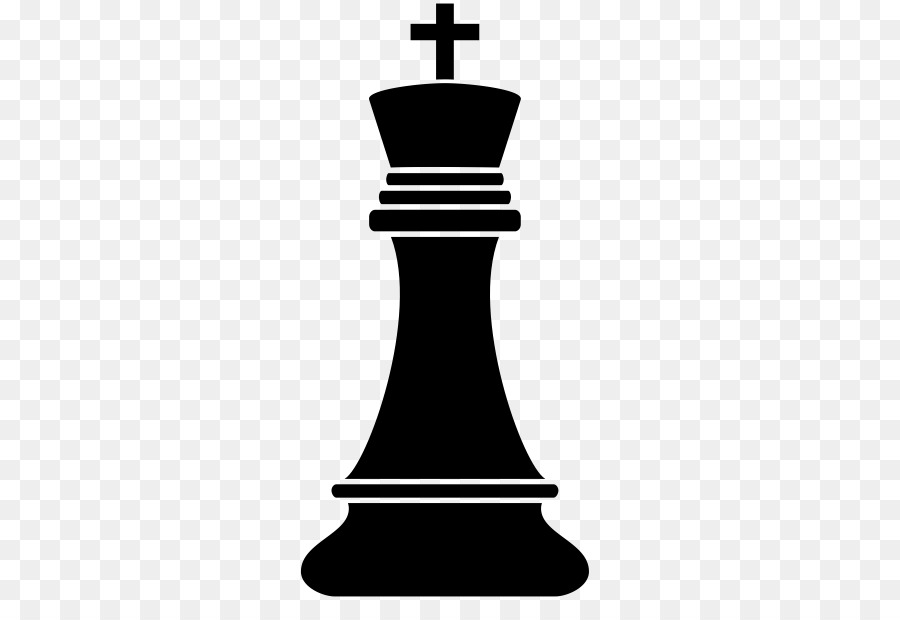

In [25]:
dataset["test"]["image"][0]

In [33]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
model = AutoModelForImageClassification.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

for img in dataset["test"]["image"][:20]:
    inputs = processor(images=img, return_tensors="pt")
    outputs = model(**inputs)
    logits = outputs.logits
    # model predicts one of the 1000 ImageNet classes
    predicted_class_idx = logits.argmax(-1).item()
    print("Predicted class:", model.config.id2label[predicted_class_idx])


Predicted class: table lamp
Predicted class: table lamp
Predicted class: joystick
Predicted class: lampshade, lamp shade
Predicted class: pedestal, plinth, footstall
Predicted class: torch
Predicted class: Indian cobra, Naja naja
Predicted class: puck, hockey puck
Predicted class: screw
Predicted class: joystick
Predicted class: vase
Predicted class: pedestal, plinth, footstall
Predicted class: pedestal, plinth, footstall
Predicted class: joystick
Predicted class: dumbbell
Predicted class: pedestal, plinth, footstall
Predicted class: quill, quill pen
Predicted class: table lamp
Predicted class: loupe, jeweler's loupe
Predicted class: pedestal, plinth, footstall


In [34]:
model

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias=True)
                  (value): Linear(in_features=96, out_features=96, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(
        

In [44]:
# Now, let's fine-tune this model using LoRA and PEFT on the ChessMan dataset. We will use the same setup
from accelerate import Accelerator
from datasets import load_dataset, DatasetDict
from transformers import AutoModelForImageClassification, AutoImageProcessor
from transformers import TrainingArguments, Trainer
from peft import LoraConfig, TaskType, get_peft_model
import numpy as np
import evaluate

# Set the device to GPU if available, otherwise use CPU

# Avoid legacy code like below:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# For pytorch 2.5 and above:
# device = torch.accelerator.current_accelerator().device \
#          if torch.accelerator.is_available() else torch.device("cpu")

# If you are using huggingface's accelerate library, you can also use:

device = Accelerator().device


# --- Initial settings for the model and dataset ---
#CHECKPOINT = "google/vit-base-patch16-224-in21k"
#CHECKPOINT = "microsoft/swin-tiny-patch4-window7-224" # does not work!
CHECKPOINT = "nvidia/mit-b0"

DATASET_PATH = "../../data/Chessman-image-dataset/Chess"
OUTPUT_DIR = "../../data/models/swin-tiny-finetuned-chessman"
LOGGING_DIR = "../../data/logs/swin-tiny-finetuned-chessman"

# --- LoRA configuration for PEFT ---

#  Target both attention and MLP layers
lora_config_swin = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # For image classification
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value", "dense"],  # Attention + MLP for Swin Transformer
)


LORA_CONFIG = lora_config_swin  # You can choose any of the above configurations

# --- Prepare the dataset for training and evaluation ---
##  Load your custom (ChessMan) dataset

dataset = load_dataset(DATASET_PATH)

# Split the dataset into training and testing sets
train_test = dataset["train"].train_test_split(test_size=0.2)
train_dataset = train_test["train"]

# Further split the testing set into validation and testing sets
test_val = train_test["test"].train_test_split(test_size=0.5)

val_dataset = test_val["train"]
test_dataset = test_val["test"]

# Organize the datasets into a dictionary
dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})
print("Dataset loaded and split into training, validation, and testing sets.")

num_classes = len(dataset["train"].features["label"].names)

# --- Prepare the model for training with PEFT ---
#model = AutoModelForImageClassification.from_pretrained(CHECKPOINT, num_labels=num_classes)
model = AutoModelForImageClassification.from_pretrained(CHECKPOINT)
model.config.num_labels = num_classes

print("-" * 50)
print(f"Model loaded: {CHECKPOINT}")
print(f"Default model trainable parameters: {model.num_parameters(only_trainable=True):,}")
print(f"Number of classes: {model.config.num_labels}")

# Apply PEFT to the model
peft_model = get_peft_model(model, LORA_CONFIG)  # You can choose any of the above configurations

print(f"PEFT applied! Trainable parameters: {peft_model.num_parameters(only_trainable=True):,}")
print("-" * 50)
print("Print PEFT printable parameters info:")
peft_model.print_trainable_parameters()
peft_model.to(device)

# --- Preprocess the images suited to the model ---

image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)

def preprocess_function(examples):
    images = [image.convert("RGB") for image in examples["image"]]
    inputs = image_processor(images=images, return_tensors="pt")
    inputs["label"] = examples["label"]
    return inputs

prepared_dataset = dataset.map(preprocess_function, batched=True)
print("Dataset prepared for training and evaluation.")

# --- Define evaluation metrics ---

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, 
                          references=labels)

# --- Setup training arguments and Trainer ---

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    
    num_train_epochs=20,
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    
    weight_decay=0.08,
    
    logging_dir=LOGGING_DIR,
    logging_strategy="epoch",
    learning_rate=5e-3,
    eval_strategy="epoch", # evaluate every epoch, alternative to "steps"
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    push_to_hub=True,    
    dataloader_pin_memory=False  # silence the warning on MacOS Apple Silicon
)

from transformers import EarlyStoppingCallback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=3,  
    early_stopping_threshold=0.01
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=prepared_dataset["train"],
    eval_dataset=prepared_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

# --- Start training the model ---
trainer.train()

# --- Save the fine-tuned model ---
peft_model.save_pretrained(OUTPUT_DIR)

Resolving data files:   0%|          | 0/553 [00:00<?, ?it/s]

Dataset loaded and split into training, validation, and testing sets.
--------------------------------------------------
Model loaded: nvidia/mit-b0
Default model trainable parameters: 3,576,392
Number of classes: 6
PEFT applied! Trainable parameters: 306,152
--------------------------------------------------
Print PEFT printable parameters info:
trainable params: 306,152 || all params: 3,882,544 || trainable%: 7.8853


/opt/anaconda3/envs/hf4_env/lib/python3.11/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Map:   0%|          | 0/442 [00:00<?, ? examples/s]

Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Map:   0%|          | 0/56 [00:00<?, ? examples/s]

Dataset prepared for training and evaluation.


TypeError: SegformerForImageClassification.forward() got an unexpected keyword argument 'input_ids'

In [40]:
prepared_dataset["train"]

Dataset({
    features: ['image', 'label', 'pixel_values'],
    num_rows: 442
})

In [43]:
checkpoint = "nvidia/mit-b0"

from transformers import AutoImageProcessor, AutoModelForImageClassification

model = AutoModelForImageClassification.from_pretrained(checkpoint)
image_processor = AutoImageProcessor.from_pretrained(checkpoint)
image_processor

preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

/opt/anaconda3/envs/hf4_env/lib/python3.11/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


SegformerImageProcessor {
  "do_normalize": true,
  "do_reduce_labels": false,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "SegformerImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 512,
    "width": 512
  }
}

In [20]:
peft.PrefixTuningConfig?

Init signature:
peft.PrefixTuningConfig(
    task_type: 'Optional[Union[str, TaskType]]' = None,
    peft_type: 'Optional[Union[str, PeftType]]' = None,
    auto_mapping: 'Optional[dict]' = None,
    peft_version: 'Optional[str]' = None,
    base_model_name_or_path: 'Optional[str]' = None,
    revision: 'Optional[str]' = None,
    inference_mode: 'bool' = False,
    num_virtual_tokens: 'int' = None,
    token_dim: 'int' = None,
    num_transformer_submodules: 'Optional[int]' = None,
    num_attention_heads: 'Optional[int]' = None,
    num_layers: 'Optional[int]' = None,
    modules_to_save: 'Optional[list[str]]' = None,
    init_weights: Optional[Literal['zero']] = None,
    encoder_hidden_size: int = None,
    prefix_projection: bool = False,
) -> None
Docstring:     
This is the configuration class to store the configuration of a [`PrefixEncoder`].

Args:
    init_weights (`Optional[str]`): If not set, weights are initialized at random, if set to "zero"
        the weights are initia

In [48]:
predictions = trainer.predict(prepared_dataset["test"])
predictions.metrics


{'test_loss': 1.239048719406128,
 'test_accuracy': 0.6785714285714286,
 'test_runtime': 2.7257,
 'test_samples_per_second': 20.545,
 'test_steps_per_second': 1.468}

In [46]:
import numpy as np
predicted_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids
print(true_labels, predicted_labels, sep="\n")

[1 3 0 3 4 2 2 1 2 2 3 3 4 3 4 5 1 0 2 4 0 1 3 5 2 2 3 0 2 4 2 2 0 5 1 1 5
 2 5 3 3 2 4 5 4 1 5 1 0 2 3 5 5 2 1 5]
[1 3 0 3 4 2 2 1 2 2 3 3 1 3 4 5 4 0 2 4 0 1 3 5 2 2 3 0 2 5 2 2 0 5 1 0 5
 2 5 0 3 2 4 5 4 1 5 1 0 2 3 5 5 2 4 5]


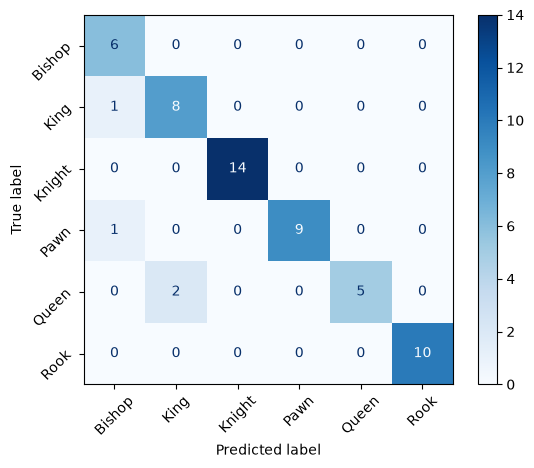

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(prepared_dataset["test"])
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
disp.ax_.set_xticklabels(prepared_dataset["test"].features["label"].names, rotation=45)
disp.ax_.set_yticklabels(prepared_dataset["test"].features["label"].names, rotation=45)
plt.show()

---

### Quantization

Quantization is a process that converts a model's floating-point numbers into lower-precision integers to reduce its size, speed up computation, and lower memory usage.

This makes it more efficient to deploy models, especially on devices with limited resources. By converting high-precision values to lower-precision ones, the model requires less memory, consumes less power, and runs faster.

**How it works**

 - **Lower precision:** Quantization takes the high-precision numbers (like 32-bit floating-point - float32) that make up a model's parameters and converts them into a smaller range of numbers, often using 8-bit integers (int8).  
 
 - **Mapping values:** The process maps the original range of floating-point values to a new, smaller range of integers. A scaling factor and zero-point are used to define this mapping.  

Quantization formula:
   x - floating point value
   S - Scaling factor
   Z - Zero-point (0 if floating-point range is negative to positive)

   q = round(x / S) + Z

   q -> final scaled integer representation of x

To retrieve the float-value (approximation):
  x_a = (S * q) - Z

Quantization error -> x - x_a



#### Example

In [51]:
import numpy as np
import torch
import matplotlib.pyplot as plt


# =============================================================================
# 1. MANUAL QUANTIZATION DEMONSTRATION
# =============================================================================

def manual_quantize_float32_to_uint8(fp_array, scale=None, zero_point=None):
    """
    Manual quantization from float32 to uint8
    Formula: quantized = round((fp_value / scale) + zero_point)
    """
    
    # Calculate quantization parameters if not provided
    if scale is None or zero_point is None:
        min_val = np.min(fp_array)
        max_val = np.max(fp_array)
        scale = (max_val - min_val) / 255.0  # uint8 range: 0-255
        zero_point = np.round(-min_val / scale)
    
    print(f"Quantization parameters:")
    print(f"  Scale: {scale:.6f}")
    print(f"  Zero point: {zero_point}")
    print(f"  Input range: [{min_val:.3f}, {max_val:.3f}]")
    print(f"  Quantized range: [0, 255]")
    
    # Quantization: float32 → uint8
    quantized = np.round((fp_array / scale) + zero_point)
    quantized = np.clip(quantized, 0, 255).astype(np.uint8)
    
    return quantized, scale, zero_point

def manual_dequantize_uint8_to_float32(quantized_array, scale, zero_point):
    """
    Dequantization from uint8 back to float32
    Formula: dequantized = (quantized - zero_point) * scale
    """
    dequantized = (quantized_array.astype(np.float32) - zero_point) * scale
    return dequantized




In [52]:
print("=== Quantization Demonstration: float32 → uint8 ===\n")

# Original float32 vector
#fp_vec = np.array([0.0, 0.1, 0.2, 0.3], dtype=np.float32)
fp_vec = np.array([-4.3345, -2.1234, 1.67, 3.14159, 2.765, 7.891, 5.0], dtype=np.float32)
print(f"Original float32 vector: {fp_vec}")
print(f"Data type: {fp_vec.dtype}")
print(f"Shape: {fp_vec.shape}\n")

print("1. MANUAL QUANTIZATION PROCESS")
print("=" * 50)
# Perform quantization
quantized_vec, scale, zero_point = manual_quantize_float32_to_uint8(fp_vec)

print(f"\nQuantization steps:")
print(f"  Original:    {fp_vec}")
print(f"  After scaling: {((fp_vec - zero_point) / scale).round(2)}")
print(f"  Quantized:    {quantized_vec}")
print(f"  Data type:    {quantized_vec.dtype}")
print(f"  Zero point:    {zero_point}")
print(f"  Scale:         {scale:.6f}")


=== Quantization Demonstration: float32 → uint8 ===

Original float32 vector: [-4.3345  -2.1234   1.67     3.14159  2.765    7.891    5.     ]
Data type: float32
Shape: (7,)

1. MANUAL QUANTIZATION PROCESS
Quantization parameters:
  Scale: 0.047943
  Zero point: 90.0
  Input range: [-4.334, 7.891]
  Quantized range: [0, 255]

Quantization steps:
  Original:    [-4.3345  -2.1234   1.67     3.14159  2.765    7.891    5.     ]
  After scaling: [-1967.63 -1921.51 -1842.39 -1811.7  -1819.55 -1712.63 -1772.93]
  Quantized:    [  0  46 125 156 148 255 194]
  Data type:    uint8
  Zero point:    90.0
  Scale:         0.047943


In [53]:

# Dequantize back to float32
dequantized_vec = manual_dequantize_uint8_to_float32(quantized_vec, scale, zero_point)

print(f"\nDequantization:")
print(f"  Quantized:    {quantized_vec}")
print(f"  After scaling: {(quantized_vec.astype(np.float32) * scale).round(4)}")
print(f"  After zero_point: {dequantized_vec}")
print(f"  Data type:    {dequantized_vec.dtype}")

# Calculate quantization error
quantization_error = np.abs(fp_vec - dequantized_vec)
print(f"\nQuantization Error:")
print(f"  Original:    {fp_vec}")
print(f"  Dequantized: {dequantized_vec}")
print(f"  Error:       {quantization_error}")
print(f"  Mean Absolute Error: {np.mean(quantization_error):.6f}")
print(f"  Max Error: {np.max(quantization_error):.6f}")



Dequantization:
  Quantized:    [  0  46 125 156 148 255 194]
  After scaling: [ 0.      2.2054  5.9929  7.4791  7.0956 12.2255  9.301 ]
  After zero_point: [-4.3148823 -2.109498   1.6780099  3.164247   2.7807019  7.910618
  4.9860864]
  Data type:    float32

Quantization Error:
  Original:    [-4.3345  -2.1234   1.67     3.14159  2.765    7.891    5.     ]
  Dequantized: [-4.3148823 -2.109498   1.6780099  3.164247   2.7807019  7.910618
  4.9860864]
  Error:       [0.01961756 0.01390195 0.00800991 0.02265692 0.01570177 0.01961803
 0.01391363]
  Mean Absolute Error: 0.016203
  Max Error: 0.022657


In [ ]:

# =============================================================================
# 2. DIFFERENT QUANTIZATION SCHEMES
# =============================================================================

print("\n\n2. DIFFERENT QUANTIZATION SCHEMES")
print("=" * 50)

# Scheme 1: Symmetric Quantization (zero_point = 0)
def symmetric_quantize(fp_array):
    """Symmetric quantization around zero"""
    max_abs = np.max(np.abs(fp_array))
    scale = max_abs / 127.0  # int8 symmetric range: -128 to 127
    
    # For uint8, we shift to positive range
    scale_sym = (2 * max_abs) / 255.0
    zero_point_sym = 127
    
    quantized = np.round((fp_array + max_abs) / scale_sym)
    quantized = np.clip(quantized, 0, 255).astype(np.uint8)
    
    return quantized, scale_sym, zero_point_sym

# Scheme 2: Asymmetric Quantization (min-max, as shown above)
def asymmetric_quantize(fp_array):
    """Asymmetric quantization using min-max range"""
    return manual_quantize_float32_to_uint8(fp_array)

# Scheme 3: Fixed-point Quantization
def fixed_point_quantize(fp_array, fractional_bits=4):
    """Fixed-point quantization with specified fractional bits"""
    # Scale factor: 2^fractional_bits
    scale_factor = 2 ** fractional_bits
    quantized = np.round(fp_array * scale_factor)
    
    # Convert to appropriate integer type
    max_val = np.max(np.abs(quantized))
    if max_val <= 127:
        dtype = np.int8
        quantized = np.clip(quantized, -128, 127).astype(dtype)
    else:
        dtype = np.int16
        quantized = np.clip(quantized, -32768, 32767).astype(dtype)
    
    return quantized, scale_factor, dtype

print("Symmetric Quantization:")
quant_sym, scale_sym, zp_sym = symmetric_quantize(fp_vec)
dequant_sym = manual_dequantize_uint8_to_float32(quant_sym, scale_sym, zp_sym)
error_sym = np.abs(fp_vec - dequant_sym)
print(f"  Quantized: {quant_sym}")
print(f"  Dequantized: {dequant_sym}")
print(f"  Error: {error_sym}")

print("\nAsymmetric Quantization:")
quant_asym, scale_asym, zp_asym = asymmetric_quantize(fp_vec)
dequant_asym = manual_dequantize_uint8_to_float32(quant_asym, scale_asym, zp_asym)
error_asym = np.abs(fp_vec - dequant_asym)
print(f"  Quantized: {quant_asym}")
print(f"  Dequantized: {dequant_asym}")
print(f"  Error: {error_asym}")

print("\nFixed-point Quantization (4 fractional bits):")
quant_fp, scale_fp, dtype_fp = fixed_point_quantize(fp_vec, fractional_bits=4)
dequant_fp = quant_fp.astype(np.float32) / scale_fp
error_fp = np.abs(fp_vec - dequant_fp)
print(f"  Quantized: {quant_fp} (dtype: {dtype_fp})")
print(f"  Dequantized: {dequant_fp}")
print(f"  Error: {error_fp}")




2. DIFFERENT QUANTIZATION SCHEMES
Symmetric Quantization:
  Quantized: [128 170 212 255]
  Dequantized: [127.30118  127.4      127.498825 127.6     ]
  Error: [127.30118  127.3      127.29883  127.299995]

Asymmetric Quantization:
Quantization parameters:
  Scale: 0.001176
  Zero point: -0.0
  Input range: [0.000, 0.300]
  Quantized range: [0, 255]
  Quantized: [  0  85 170 255]
  Dequantized: [0.         0.10000001 0.20000002 0.3       ]
  Error: [0.0000000e+00 7.4505806e-09 1.4901161e-08 0.0000000e+00]

Fixed-point Quantization (4 fractional bits):
  Quantized: [0 2 3 5] (dtype: <class 'numpy.int8'>)
  Dequantized: [0.     0.125  0.1875 0.3125]
  Error: [0.         0.025      0.0125     0.01249999]


In [30]:

# =============================================================================
# 3. PYTORCH QUANTIZATION API
# =============================================================================

print("\n\n3. PYTORCH QUANTIZATION API")
print("=" * 50)

# Convert to PyTorch tensor
fp_tensor = torch.tensor(fp_vec, dtype=torch.float32)
print(f"PyTorch tensor: {fp_tensor}")
print(f"Data type: {fp_tensor.dtype}")

# Method 1: Using torch.quantize_per_tensor (for int8)
# Note: PyTorch's quantize_per_tensor works with int8, not uint8 directly
quantized_tensor = torch.quantize_per_tensor(
    fp_tensor, 
    scale=scale, 
    zero_point=int(zero_point), 
    dtype=torch.quint8  # unsigned int8
)

print(f"\nPyTorch Quantized Tensor:")
print(f"  Values: {quantized_tensor.int_repr()}")  # Get integer values
print(f"  Scale: {quantized_tensor.q_scale()}")
print(f"  Zero point: {quantized_tensor.q_zero_point()}")
print(f"  Data type: {quantized_tensor.dtype}")

# Dequantize
dequantized_tensor = quantized_tensor.dequantize()
print(f"\nDequantized Tensor:")
print(f"  Values: {dequantized_tensor}")
print(f"  Error: {torch.abs(fp_tensor - dequantized_tensor)}")




3. PYTORCH QUANTIZATION API
PyTorch tensor: tensor([-4.3345, -2.1234,  1.6700,  3.1416,  5.0000])
Data type: torch.float32

PyTorch Quantized Tensor:
  Values: tensor([  0,  60, 164, 204, 255], dtype=torch.uint8)
  Scale: 0.03660587966442108
  Zero point: 118
  Data type: torch.quint8

Dequantized Tensor:
  Values: tensor([-4.3195, -2.1231,  1.6839,  3.1481,  5.0150])
  Error: tensor([0.0150, 0.0003, 0.0139, 0.0065, 0.0150])


In [ ]:

# Method 2: Manual quantization in PyTorch
def pytorch_manual_quantize(tensor, num_bits=8):
    """Manual quantization in PyTorch"""
    min_val = tensor.min()
    max_val = tensor.max()
    
    scale = (max_val - min_val) / (2 ** num_bits - 1)
    zero_point = torch.round(-min_val / scale)
    
    # Quantize
    quantized = torch.round((tensor - zero_point) / scale)
    quantized = torch.clamp(quantized, 0, 255).to(torch.uint8)
    
    return quantized, scale, zero_point

quant_pt, scale_pt, zp_pt = pytorch_manual_quantize(fp_tensor)
dequant_pt = quant_pt.float() * scale_pt + zp_pt

print(f"\nPyTorch Manual Quantization:")
print(f"  Quantized: {quant_pt}")
print(f"  Dequantized: {dequant_pt}")
print(f"  Error: {torch.abs(fp_tensor - dequant_pt)}")



PyTorch Manual Quantization:
  Quantized: tensor([  0,  85, 170, 255], dtype=torch.uint8)
  Dequantized: tensor([0.0000, 0.1000, 0.2000, 0.3000])
  Error: tensor([0.0000e+00, 7.4506e-09, 1.4901e-08, 0.0000e+00])




4. QUANTIZATION EFFECTS VISUALIZATION
Quantization parameters:
  Scale: 0.007843
  Zero point: 128.0
  Input range: [-1.000, 1.000]
  Quantized range: [0, 255]


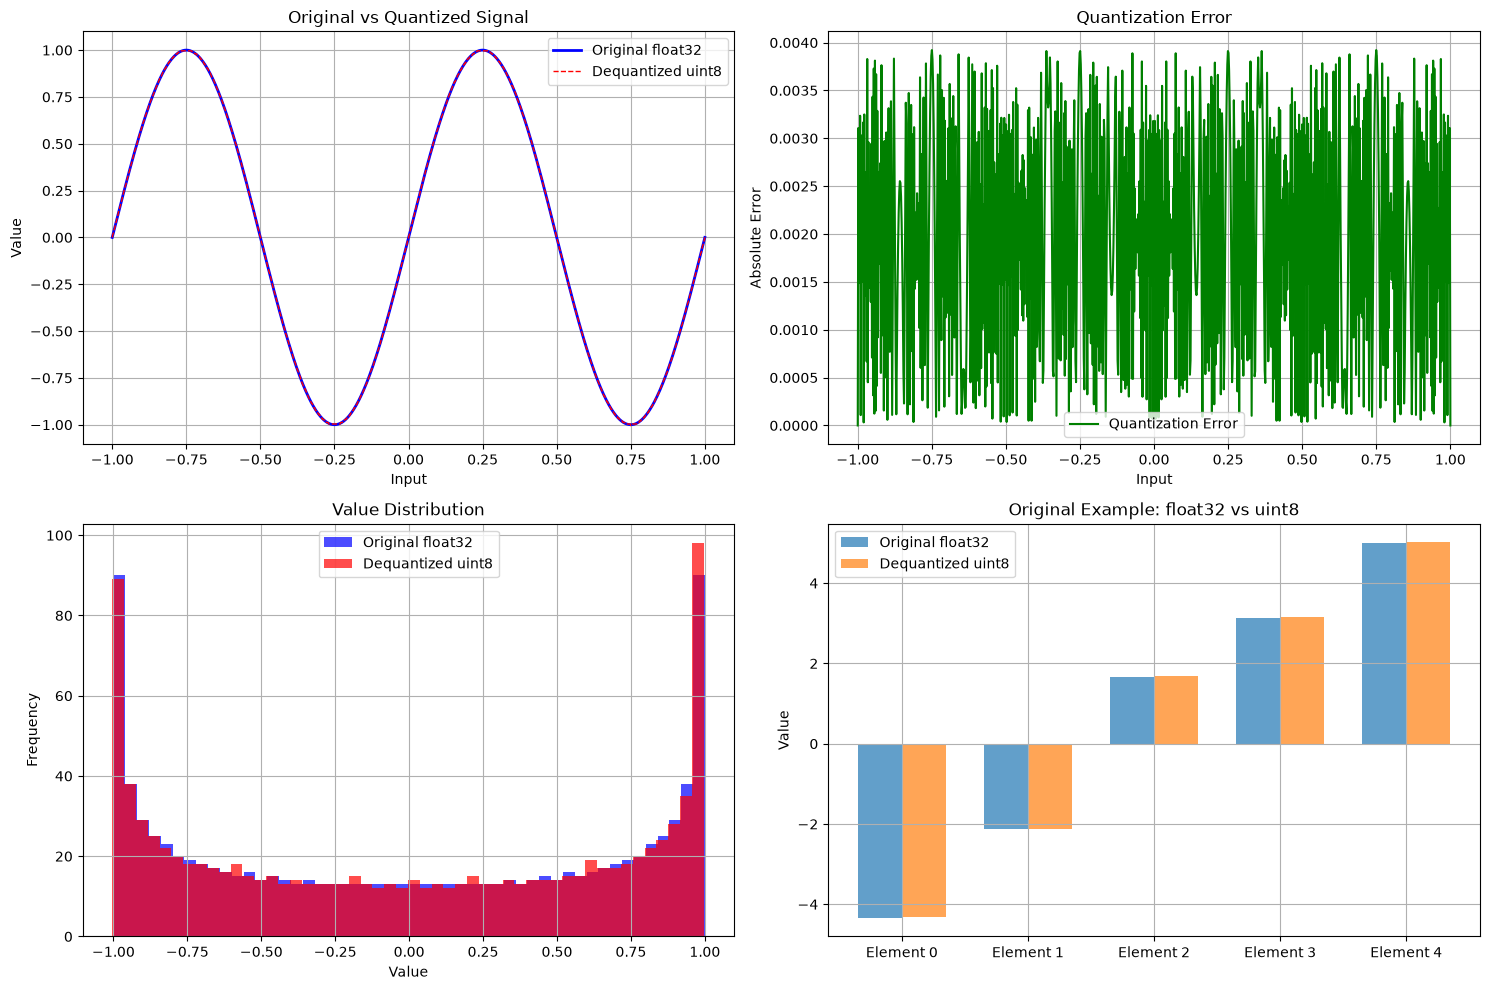

In [31]:

# =============================================================================
# 4. VISUALIZATION OF QUANTIZATION EFFECTS
# =============================================================================

print("\n\n4. QUANTIZATION EFFECTS VISUALIZATION")
print("=" * 50)

# Create a larger example to visualize
x_smooth = np.linspace(-1, 1, 1000, dtype=np.float32)
y_smooth = np.sin(x_smooth * 2 * np.pi)  # Sine wave

# Quantize the smooth curve
y_quantized, scale_large, zp_large = manual_quantize_float32_to_uint8(y_smooth)
y_dequantized = manual_dequantize_uint8_to_float32(y_quantized, scale_large, zp_large)

plt.figure(figsize=(15, 10))

# Plot 1: Original vs Quantized
plt.subplot(2, 2, 1)
plt.plot(x_smooth, y_smooth, 'b-', label='Original float32', linewidth=2)
plt.plot(x_smooth, y_dequantized, 'r--', label='Dequantized uint8', linewidth=1)
plt.title('Original vs Quantized Signal')
plt.xlabel('Input')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

# Plot 2: Quantization Error
plt.subplot(2, 2, 2)
quant_error = np.abs(y_smooth - y_dequantized)
plt.plot(x_smooth, quant_error, 'g-', label='Quantization Error')
plt.title('Quantization Error')
plt.xlabel('Input')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)

# Plot 3: Histogram of values
plt.subplot(2, 2, 3)
plt.hist(y_smooth, bins=50, alpha=0.7, label='Original float32', color='blue')
plt.hist(y_dequantized, bins=50, alpha=0.7, label='Dequantized uint8', color='red')
plt.title('Value Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

# Plot 4: Our original example
plt.subplot(2, 2, 4)
x_pos = np.arange(len(fp_vec))
width = 0.35

plt.bar(x_pos - width/2, fp_vec, width, label='Original float32', alpha=0.7)
plt.bar(x_pos + width/2, dequantized_vec, width, label='Dequantized uint8', alpha=0.7)
plt.xticks(x_pos, [f'Element {i}' for i in range(len(fp_vec))])
plt.title('Original Example: float32 vs uint8')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [32]:
!pip install bitsandbytes

In [ ]:
from transformers import AutoModelForImageClassification, AutoImageProcessor, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
model = AutoModelForImageClassification.from_pretrained(CHECKPOINT, 
    num_labels=num_classes,
    quantization_config=bnb_config
)

More details on the theory: https://huggingface.co/docs/optimum/en/concept_guides/quantization

---